In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt

In [36]:
df = pd.read_csv("WISDM_ar_v1.1_raw.txt", header=None, on_bad_lines='skip')
df.columns = ['user', 'activity', 'timestamp', 'acc_x', 'acc_y', 'acc_z']

In [37]:
df['acc_z'] = df['acc_z'].astype(str).str.replace(';','')
df['acc_z'] = df['acc_z'].astype(float)
df['acc_x'] = df['acc_x'].astype(float)
df['acc_y'] = df['acc_y'].astype(float)
df['timestamp'] = df['timestamp'].astype(float)

In [38]:
df['magnitude'] = np.sqrt(df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)

In [39]:
def butter_lowpass_filter(data, cutoff=3, fs=20, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

df['mag_filtered'] = butter_lowpass_filter(df['magnitude'])

In [40]:
X = df[['acc_x','acc_y','acc_z']]
y = df['activity']

X_filtered = X.rolling(window=5).mean().dropna()
y = y.iloc[4:]

In [41]:
window_size = 50
step_size = 25

X_windows = []
y_windows = []

for i in range(0, len(X_filtered) - window_size, step_size):
    window = X_filtered.iloc[i:i+window_size]
    
    features = [
        window['acc_x'].mean(),
        window['acc_y'].mean(),
        window['acc_z'].mean(),
        window['acc_x'].std(),
        window['acc_y'].std(),
        window['acc_z'].std()
    ]
    
    X_windows.append(features)
    y_windows.append(y.iloc[i:i+window_size].mode()[0])

X_windows = np.array(X_windows)
y_windows = np.array(y_windows)

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_windows, y_windows, test_size=0.2, random_state=42
)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [44]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=150, max_depth=15)
model.fit(X_train, y_train
         )

,n_estimators,150
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
unseen_X = X_windows[-10:]
unseen_y_actual = y_windows[-10:]

unseen_X = scaler.transform(unseen_X)

unseen_y_pred = model.predict(unseen_X)

comparison_df = pd.DataFrame({
    "Actual": unseen_y_actual,
    "Predicted": unseen_y_pred
})

print("\n===== UNSEEN DATA TEST RESULTS =====")
print(comparison_df)

from sklearn.metrics import accuracy_score
print("\nUnseen Data Accuracy:", accuracy_score(unseen_y_actual, unseen_y_pred))


===== UNSEEN DATA TEST RESULTS =====
    Actual Predicted
0  Sitting   Sitting
1  Sitting   Sitting
2  Sitting   Sitting
3  Sitting   Sitting
4  Sitting   Sitting
5  Sitting   Sitting
6  Sitting   Sitting
7  Sitting   Sitting
8  Sitting   Sitting
9  Sitting   Sitting

Unseen Data Accuracy: 1.0



Accuracy: 0.9052001840773125
Precision: 0.9047026882328473
Recall: 0.9052001840773125
F1 Score: 0.898867123178314


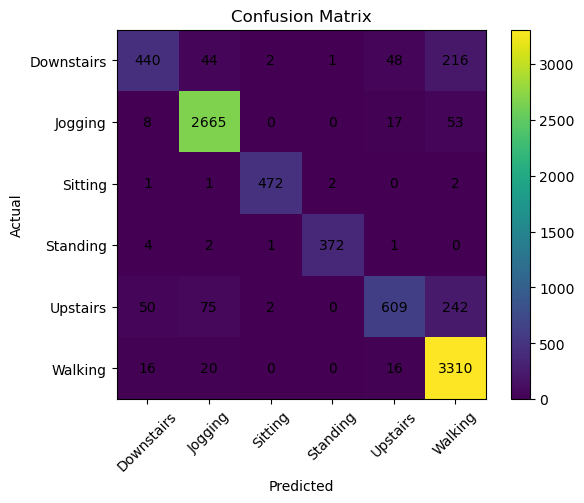

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

classes = sorted(set(y_test))
plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
user_id = int(input("\nEnter User ID: "))
user_df = df[df['user'] == user_id]

user_df = user_df[user_df['activity'] != "Standing"]

mag = np.sqrt(user_df['acc_x']**2 + user_df['acc_y']**2 + user_df['acc_z']**2)
mag = butter_lowpass_filter(mag)

peaks, _ = find_peaks(mag, height=np.mean(mag))
total_steps = len(peaks)

# calories (approx)
total_calories = total_steps * 0.05

print("\n===== USER SUMMARY =====")
print("User:", user_id)
print("Total Steps:", total_steps)
print("Calories:", round(total_calories,2))


Enter User ID:  36



===== USER SUMMARY =====
User: 36
Total Steps: 2725
Calories: 136.25


In [52]:
distance_km = (total_steps * 0.75) / 1000
print("Distance (km):", round(distance_km,2))

Distance (km): 2.04


In [53]:
user_steps_all = {}

for user in df['user'].unique():
    temp_df = df[df['user'] == user]
    temp_df = temp_df[temp_df['activity'] != "Standing"]
    
    mag = np.sqrt(temp_df['acc_x']**2 + temp_df['acc_y']**2 + temp_df['acc_z']**2)
    mag = butter_lowpass_filter(mag)
    
    peaks, _ = find_peaks(mag, height=np.mean(mag))
    user_steps_all[user] = len(peaks)

top_user = max(user_steps_all, key=user_steps_all.get)

print("\nTop Active User:", top_user)
print("Steps:", user_steps_all[top_user])


Top Active User: 19
Steps: 4064


In [54]:
goal = 5000

if total_steps >= goal:
    print("Goal Achieved 🎉 Excellent work!")
else:
    print("Goal Not Reached ❌ Try to be more active!")

print("\nSuggestion:")

if total_steps < 3000:
    print("😴 Very low activity. Try walking more!")
elif total_steps < 7000:
    print("🙂 Good, but you can improve!")
else:
    print("🔥 Excellent! Keep it up!")

print("❤️ Stay healthy!")

Goal Not Reached ❌ Try to be more active!

Suggestion:
😴 Very low activity. Try walking more!
❤️ Stay healthy!


In [55]:
# ===================== NEW CELL START =====================

# USER-WISE TOTAL STEPS + CALORIES TABLE

user_summary = []

for user in df['user'].unique():
    temp_df = df[df['user'] == user]
    
    # ignore standing
    temp_df = temp_df[temp_df['activity'] != "Standing"]
    
    if len(temp_df) < 20:
        continue
    
    # magnitude + filter
    mag = np.sqrt(temp_df['acc_x']**2 + temp_df['acc_y']**2 + temp_df['acc_z']**2)
    mag = butter_lowpass_filter(mag)
    
    # steps
    peaks, _ = find_peaks(mag, height=np.mean(mag))
    steps = len(peaks)
    
    # calories
    calories = steps * 0.05
    
    user_summary.append([user, steps, round(calories,2)])

# create dataframe
summary_df = pd.DataFrame(user_summary, columns=["User","Total Steps","Calories"])

print("\n===== USER FITNESS TABLE =====")

# sort by steps (nice look)
summary_df = summary_df.sort_values(by="Total Steps", ascending=False)

# print clean table
print(summary_df.to_string(index=False))

# TOP USER
top_user = summary_df.iloc[0]

print("\n🏆 Top Performer of the Day:")
print(f"User {int(top_user['User'])} with {int(top_user['Total Steps'])} steps!")

# appreciation
print("👏 Amazing consistency! Keep it up!")

# ===================== NEW CELL END =====================


===== USER FITNESS TABLE =====
 User  Total Steps  Calories
   19         4064    203.20
   31         3986    199.30
   34         3606    180.30
    3         3547    177.35
   14         3540    177.00
   29         3488    174.40
    8         3456    172.80
   10         3439    171.95
    1         3431    171.55
   20         3417    170.85
   26         3294    164.70
   13         3237    161.85
   27         3219    160.95
   12         3030    151.50
   18         3022    151.10
   15         2931    146.55
   32         2927    146.35
    5         2771    138.55
    6         2764    138.20
   36         2725    136.25
    2         2711    135.55
    7         2629    131.45
   23         2580    129.00
   33         2464    123.20
   24         2424    121.20
   35         2362    118.10
   22         2202    110.10
   17         2116    105.80
   21         2014    100.70
   28         1862     93.10
   30         1834     91.70
   25         1522     76.10
   16      